<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/expreriment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=========== EDGE DEVICE ===========
Current Air Pressure : 1003 hPa
Stored at Edge : 26

=========== CLOUD ===========
Cloud Records : 26
Mean : 1013.96 hPa
Moving Average : 1007.2 hPa
Standard Deviation : 4.97 hPa
Status : NORMAL


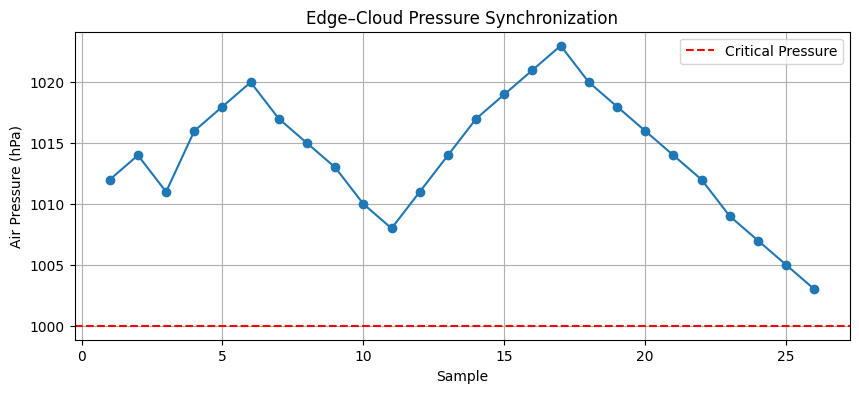

KeyboardInterrupt: 

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

edge_storage = []
cloud_storage = []
time_data = []

# Realistic varying air pressure dataset (50 samples)

pressure_values = [
1012, 1014, 1011, 1016, 1018, 1020, 1017, 1015, 1013, 1010,
1008, 1011, 1014, 1017, 1019, 1021, 1023, 1020, 1018, 1016,
1014, 1012, 1009, 1007, 1005, 1003, 1001, 1004, 1006, 1008,
1010, 1012, 1015, 1017, 1019, 1022, 1024, 1021, 1018, 1016,
1013, 1010, 1007, 1004, 1002, 1000, 998, 1001, 1003, 1005
]

for i in range(1, 51):
    pressure = pressure_values[i - 1]

    # Edge Storage
    edge_storage.append(pressure)

    # Synchronize to Cloud
    cloud_storage.append(pressure)

    time_data.append(i)

    mean = np.mean(cloud_storage)
    std = np.std(cloud_storage)

    if len(cloud_storage) >= 5:
        moving = np.mean(cloud_storage[-5:])
    else:
        moving = mean

    if pressure < 1000:
        status = "LOW PRESSURE"
    else:
        status = "NORMAL"

    clear_output(wait=True)

    print("=========== EDGE DEVICE ===========")
    print("Current Air Pressure :", pressure, "hPa")
    print("Stored at Edge :", len(edge_storage))
    print()

    print("=========== CLOUD ===========")
    print("Cloud Records :", len(cloud_storage))
    print("Mean :", round(mean, 2), "hPa")
    print("Moving Average :", round(moving, 2), "hPa")
    print("Standard Deviation :", round(std, 2), "hPa")
    print("Status :", status)

    plt.figure(figsize=(10, 4))
    plt.plot(time_data, cloud_storage, marker='o')
    plt.axhline(1000, color='red', linestyle='--', label='Critical Pressure')
    plt.xlabel("Sample")
    plt.ylabel("Air Pressure (hPa)")
    plt.title("Edge–Cloud Pressure Synchronization")
    plt.legend()
    plt.grid(True)
    plt.show()

    time.sleep(0.5)

df = pd.DataFrame({
    "Sample": time_data,
    "Air Pressure": cloud_storage
})

df.to_csv("cloud_pressure_data.csv", index=False)

print("Experiment Completed Successfully")